In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy
import copy

from scipy.sparse import coo_matrix, block_diag, identity, hstack, csr_matrix, csc_matrix, vstack
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import time 

from pyiga import assemble, bspline, vform, geometry, vis, solvers, utils, topology, ieti, algebra, operators, adaptive
from pyiga import algebra_cy, ieti_cy, bspline_cy

from scipy.sparse.linalg import aslinearoperator as LinOp

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
def Lshape(deg, N, k=1):
    kvs = [2 * (bspline.make_knots(deg, 0.0, 1.0, N, mult=k),),2 * (bspline.make_knots(deg, 0.0, 1.0, N, mult=k),)]

    # define geometry
    geos = [
        geometry.Quad(np.array([[-1,-1],[0,-1],[-1,1],[0,0]]).T),
        geometry.Quad(np.array([[-1,1],[0,0],[1,1],[1,0]]).T)
    ]

    patches = [(k, g) for k, g in zip(kvs,geos)]
    M = topology.MultiPatch(patches)
    return M

In [4]:
def LshapeAnullus(deg, N, k=1):
    kvs = 3*[2 * (bspline.make_knots(deg, 0.0, 1.0, N, mult=k),)]

    # define geometry
    geos = [
        geometry.annulus(r1=1.5, r2=2, phi = np.pi/4),
        geometry.annulus(r1=1.5, r2=2, phi = np.pi/4).rotate_2d(angle=np.pi/4),
        geometry.annulus(r1=1.0, r2=1.5, phi = np.pi/4).rotate_2d(angle=np.pi/4),
    ]

    patches = [(k, g) for k, g in zip(kvs,geos)]
    M = topology.MultiPatch(patches)
    M.outer_boundaries[0].add((1,(0,0)))
    return M

In [5]:
def cart2pol(x, y):
    r = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    return(r, phi%(2*np.pi))
def u(x,y):
    r, phi = cart2pol(x,y)
    return r**(2/3)*np.sin(2*phi/3)
def ux(x,y):
    r, phi = cart2pol(x,y)
    return -2./3*r**(-1./3)*np.sin(phi/3)
def uy(x,y):
    r, phi = cart2pol(x,y)
    return 2./3*r**(-1./3)*np.cos(phi/3)

In [6]:
f = 0
dir_data= {0:u}

In [38]:
degs = (2,3,5,8)
maxpatches =(3000,2500,2000,1500)
maxiter=(7,7,7,6)
eps=(1e-6,1e-7,1e-7,1e-7)
plot=1

R = np.zeros((max(maxiter),len(degs)*5))

for i,deg in enumerate(degs):
    print("#########################################")
    N = deg+1
    M = Lshape(deg,N,1)

    MB = assemble.MultiBasis(M, subspace='C0')
    eta=1.0
    k=0
    while k<maxiter[i]:
        # if plot:
        #     M.plotmesh(figsize=(10,10), knots=1, nodes=50, bwidth=0.01, patch_idx=0)
        #     plt.axis('off');
        #     plt.axis('scaled');
        #     plt.savefig('/home/wolfman/Pictures/p'+str(deg)+'i'+str(k)+'.png',dpi=100,bbox_inches='tight');
        #     plt.show();
        #     plt.close();
            
        ### SOLVE
        R[k,i*5] = MB.nDofs
        R[k,i*5+1] = MB.nPatches
        
        dir_bcs = MB.set_fixed_boundary(dir_data, local=False)
        Mh = MB.assemble_volume("u * v * dx", arity=2, domain_id=0)
        Kh = MB.assemble_volume("inner(grad(u),grad(v)) * dx", arity=2, domain_id=0)
        Fh = MB.assemble_volume("(f * v) * dx", arity=1, domain_id=0, f=f)
        LS = assemble.RestrictedLinearSystem(Kh, Fh, dir_bcs)
        Uh = MB.assemble_volume("(f * v) * dx", arity=1, domain_id=0, f=u)
        uh = LS.complete(solvers.make_solver(LS.A, spd=True)@LS.b)
        u_exact = operators.make_solver(Mh,spd=True)@Uh

        #MB.plot(uh, mesh=True)
        #plt.show();

        eh = uh - u_exact
        Eerr = np.sqrt(eh@Kh@eh)
        R[k,i*5+2] = Eerr

        err_ind=adaptive.mp_resPois(MB, uh, nu=1, f=f)
        eta = np.linalg.norm(err_ind)
        #R[k,i*5+3] = eta
        #R[k,i*5+4] = eta/Eerr

        print(Eerr)
        # print(eta)
        # print(eta/Eerr)

        # marked_patches = adaptive.doerfler_mark(err_ind, theta=0.8, TOL=0.01)
        # marked_patches = {p:None for p in marked_patches}

        if MB.nPatches + 3*len(marked_patches) >= maxpatches[i]:
            break;

        if eta < eps[i]:
            break;

        MB.h_refine(h_ref=-1,ref="rs", return_P = False, in_subspace=True)
        k+=1
np.save('Lshape_uniform',R)

#########################################
setting up constraints took 0.0014622211456298828 seconds.
Basis setup took 0.001687765121459961 seconds
0.06045378621717978
setting up constraints took 0.001791238784790039 seconds.
Basis setup took 0.002067089080810547 seconds
0.04198162480599845
setting up constraints took 0.0035123825073242188 seconds.
Basis setup took 0.003393411636352539 seconds
0.02799106932523306
setting up constraints took 0.0019295215606689453 seconds.
Basis setup took 0.002060413360595703 seconds
0.018169099873008823
setting up constraints took 0.002290487289428711 seconds.
Basis setup took 0.0022020339965820312 seconds
0.011622126513000567
setting up constraints took 0.0029478073120117188 seconds.
Basis setup took 0.002695322036743164 seconds
0.00737818407515212
setting up constraints took 0.004980564117431641 seconds.
Basis setup took 0.004674196243286133 seconds
0.004666002604487757
setting up constraints took 0.010855436325073242 seconds.
Basis setup took 0.01235

In [7]:
R_a = np.load('Lshape_adaptive.npy')
R_u = np.load('Lshape_uniform.npy')

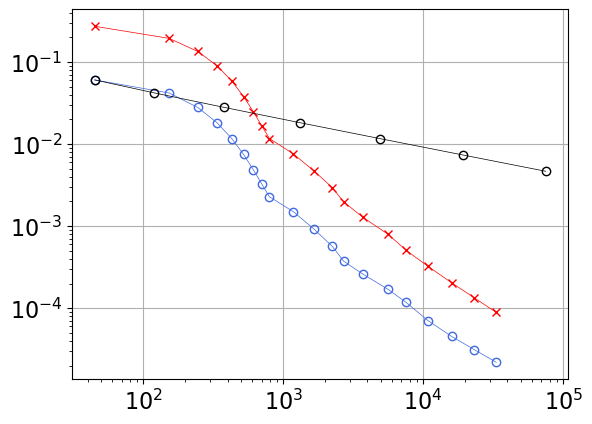

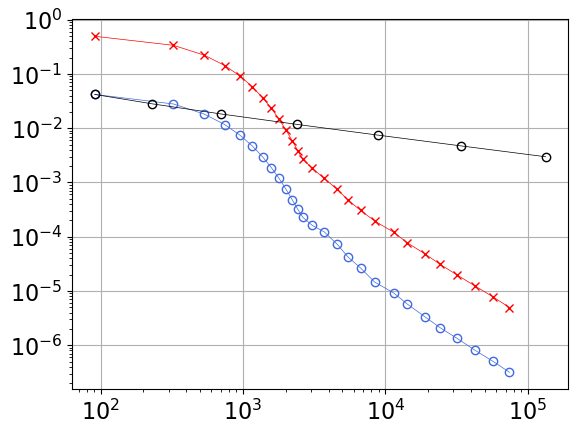

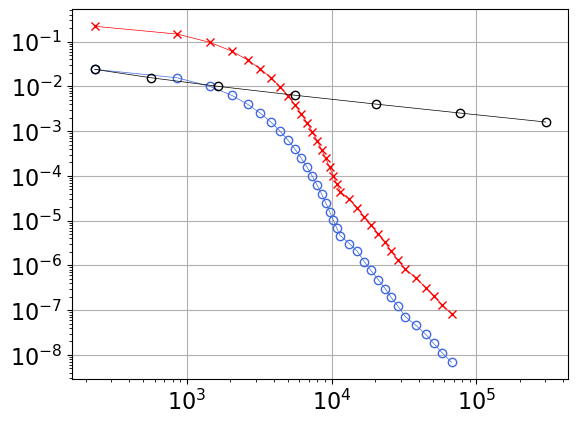

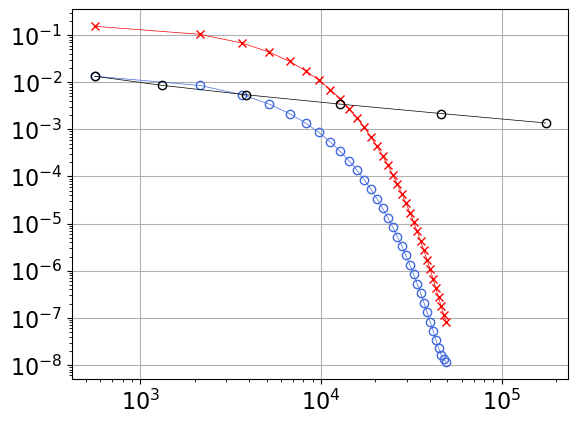

In [17]:
numdofs=R_u[:,0]
numdofs_a = R_a[:,0]
Eerr = R_u[:,2]
Eerr_a = R_a[:,2]
for i in range(4):
    numdofs=R_u[:,i*5+0]
    numdofs_a = R_a[:,i*5+0]
    Eerr = R_u[:,i*5+2]
    Eerr_a = R_a[:,i*5+2]
    Eta = R_a[:,i*5+3]

    numdofs=numdofs[numdofs!=0]
    numdofs_a=numdofs_a[numdofs_a != 0]
    Eerr_a = Eerr_a[Eerr_a!=0]
    Eerr = Eerr[Eerr!=0]
    Eta = Eta[Eta!=0]
    
    fig, ax = plt.subplots()
    plt.loglog(numdofs_a, Eerr_a, 'o-',color='royalblue',linewidth=0.5, markerfacecolor='none')
    plt.loglog(numdofs_a, Eta, 'x-',color='red',linewidth=0.5, markerfacecolor='none')
    plt.loglog(numdofs, Eerr, 'o-',color='black',linewidth=0.5, markerfacecolor='none')
    plt.grid('True');
    ax.tick_params(axis='both', labelsize=16)
    plt.show()